# 08 — Input-level climatological patching: causal sensitivity of Aurora's forecast

**Idea** (input-level, not hidden-state): replace ONE physical component of the model's input
(both input timesteps) with its climatological mean for that day-of-year/hour, keep everything
else real, run the full 4-step (6h) rollout, and compare against an unpatched baseline (all
real input). Unlike the hidden-state/attention skeleton decomposition in notebook 07 (passive
observation of representations), this is a **causal ablation**: we actually remove real
information from the input and measure what happens to the forecast.

**Two cases**: Typhoon Bebinca (init=2024-09-15, valid +6h..+24h through the 2024-09-16
landfall) and a quiet control (init=2024-11-15, no typhoon near China) -- run identically, so
any storm-specific sensitivity can be told apart from generic model behavior.

**Components patched** (one at a time):
- `surface_mslp` — mean sea level pressure (surface, full climatology available)
- `wind` — 10m u/v (surface) + upper u/v (partial column, see caveat below)
- `mass_field` — upper geopotential (partial column)
- `temperature` — upper temperature (partial column)
- `t2m` — 2m temperature (surface, full climatology available)

**Caveat (important)**: our downloaded WB2 climatology only covers 3 pressure levels (500,
850, 1000 hPa) for upper-air variables, out of the 13 levels Aurora uses. So `wind`,
`mass_field`, and `temperature` patches are **partial-column**: only those 3 levels are
replaced by climatology, the other 10 stay real. `surface_mslp` and `t2m` have no such
restriction.

**Two spatial scopes**: `global` (climatology substituted everywhere) and `regional` (only
inside the China/typhoon crop box, rest of the globe stays real).

**Metrics** (per date × component × scope × output variable × lead time):
1. `metric1_rmse_patch_baseline` = RMSE(patched, baseline) — raw sensitivity, no ground truth needed.
2. `metric2_delta_rmse_vs_truth` = RMSE(patched, truth) − RMSE(baseline, truth) — positive means
   the patch made the forecast *worse* (that input mattered for accuracy).
3. `metric3_delta_acc` = ACC(patched, truth, clim) − ACC(baseline, truth, clim) — impact on
   anomaly correlation.
4. `metric4_relative_sensitivity` = metric1 / std(truth field) — unit-free, comparable across
   variables with different physical units.
5. `weighted_rmse_area` — metric 1 but area-weighted (cos(latitude)), correcting for
   grid-cell-area distortion near the poles.
6. `weighted_rmse_storm` (storm case only) — metric 1 weighted by a Gaussian centered on the
   truth MSLP-minimum (storm track proxy, sigma=5°) × cos(latitude) — emphasizes sensitivity
   *right at the storm*, not spread evenly over the whole domain.

Outputs of every run (baseline + all patched variants, both dates) were saved to
`results/patching_experiment/{storm,quiet}.npz` (~6.7GB each) so nothing needs to be rerun to
revisit this analysis.

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

plt.rcParams['figure.dpi'] = 110
RESULTS_DIR = os.path.expanduser('~/weather-interpretability/results/patching_experiment')
FIG_DIR = 'figures/08_input_patching'
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_pickle(os.path.join(RESULTS_DIR, 'metrics_summary.pkl'))
with open(os.path.join(RESULTS_DIR, 'error_maps.pkl'), 'rb') as f:
    maps_data = pickle.load(f)
maps, lat_full, lon_full = maps_data['maps'], maps_data['lat'], maps_data['lon']

COMPONENTS = ['surface_mslp', 'wind', 'mass_field', 'temperature', 't2m']
CORE_VARS = ['MSLP', 'T2M', 'Z500', 'Z850', 'T850', 'U850', 'V850']
CHINA_EXTENT = [95, 130, 15, 45]
print(df.shape)
df.head()

(560, 14)


,date,lead_hours,component,scope,var,unit,metric1_rmse_patch_baseline,metric2_delta_rmse_vs_truth,metric3_delta_acc,metric4_relative_sensitivity,weighted_rmse_area,weighted_rmse_storm,rmse_baseline_truth,rmse_patched_truth
0,storm,6,surface_mslp,global,MSLP,hPa,5.638743,5.381847,-0.158426,0.410139,4.756760,4.039185,0.239225,5.621072
1,storm,6,surface_mslp,regional,MSLP,hPa,0.393813,0.225296,-0.001283,0.028644,0.463459,3.771514,0.239225,0.464521
2,storm,6,wind,global,MSLP,hPa,1.869828,1.656863,-0.016560,0.136003,1.755970,2.272610,0.239225,1.896089
3,storm,6,wind,regional,MSLP,hPa,0.123280,0.028924,-0.000119,0.008967,0.141542,1.684431,0.239225,0.268149
4,storm,6,mass_field,global,MSLP,hPa,0.823027,0.616829,-0.005331,0.059864,0.670825,0.617562,0.239225,0.856055


## 1. Sensitivity matrix — which input drives which output? (+24h, global patch)

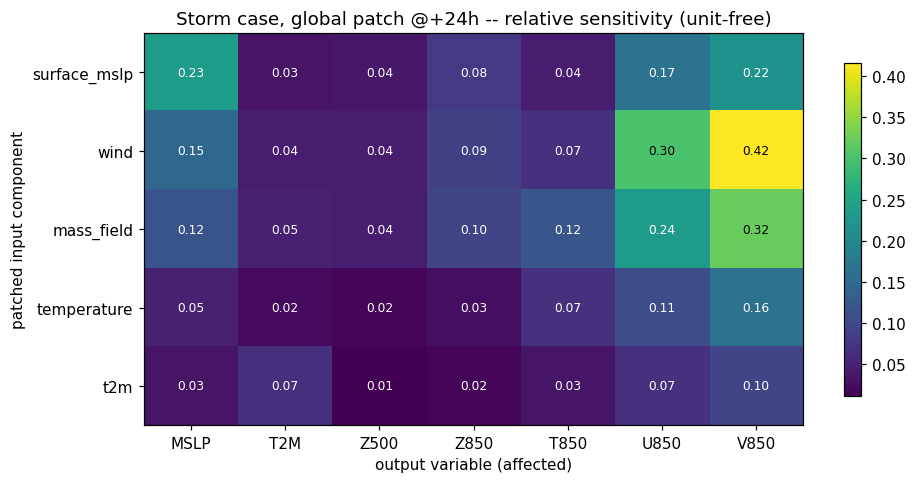

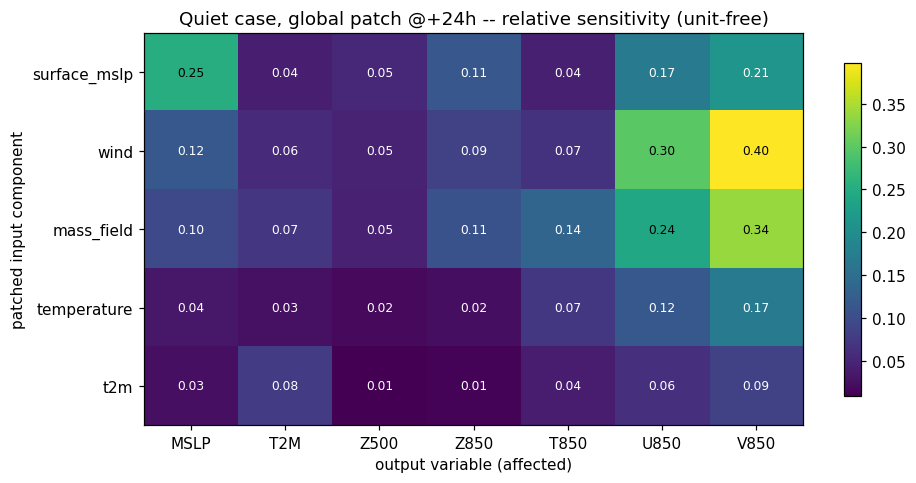

In [2]:
def plot_sensitivity_matrix(date_label, scope, metric_col, title, cmap='viridis', fmt='{:.2f}'):
    sub = df[(df.date == date_label) & (df.scope == scope) & (df.lead_hours == 24)]
    mat = sub.pivot(index='component', columns='var', values=metric_col).reindex(
        index=COMPONENTS, columns=CORE_VARS)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    im = ax.imshow(mat.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(CORE_VARS)))
    ax.set_xticklabels(CORE_VARS)
    ax.set_yticks(range(len(COMPONENTS)))
    ax.set_yticklabels(COMPONENTS)
    ax.set_xlabel('output variable (affected)')
    ax.set_ylabel('patched input component')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, fmt.format(mat.values[i, j]), ha='center', va='center',
                     color='white' if mat.values[i, j] < np.nanmax(mat.values) * 0.6 else 'black', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_title(title)
    plt.tight_layout()
    safe = title.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '').replace(',', '')
    plt.savefig(f'{FIG_DIR}/{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_sensitivity_matrix('storm', 'global', 'metric4_relative_sensitivity',
                         'Storm case, global patch @+24h -- relative sensitivity (unit-free)')
plot_sensitivity_matrix('quiet', 'global', 'metric4_relative_sensitivity',
                         'Quiet case, global patch @+24h -- relative sensitivity (unit-free)')

Rows = which input component was replaced by climatology; columns = which output variable's
forecast changed as a result (relative to std of that variable's own truth field, so units
cancel and rows/columns are comparable). Diagonal-ish structure (each component most strongly
affecting its "own" physical variable) would indicate mostly local effects; strong off-diagonal
entries (e.g. `surface_mslp` affecting `Z500`/`Z850`) indicate the model enforces physical
coupling between fields (mass-wind balance) rather than treating each variable independently.

## 2. Does patching make the forecast worse? (ΔRMSE vs ground truth)

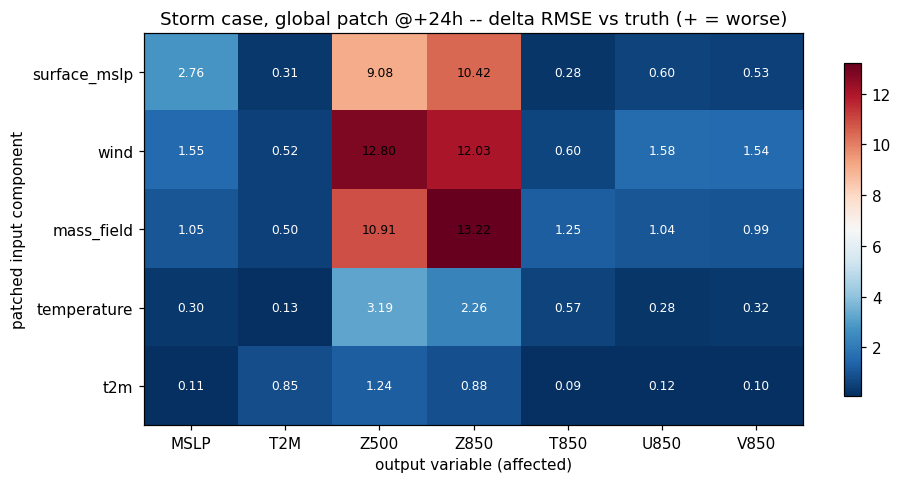

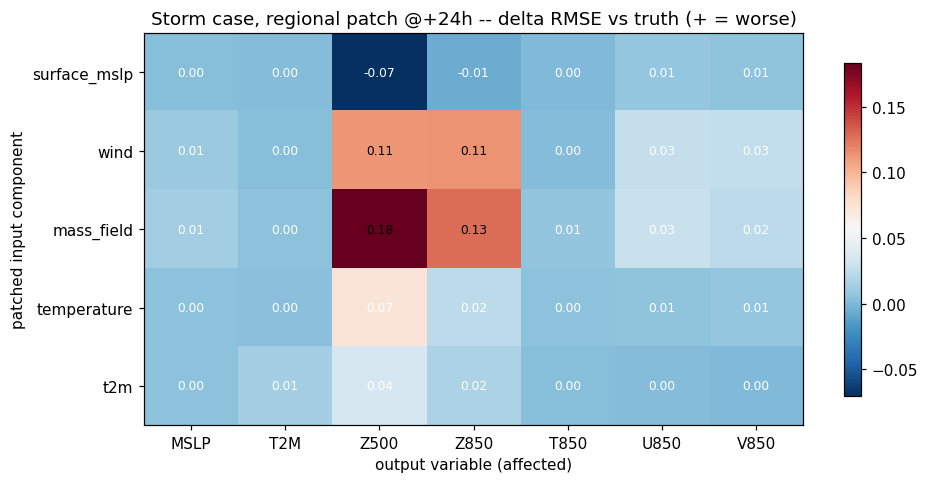

In [3]:
plot_sensitivity_matrix('storm', 'global', 'metric2_delta_rmse_vs_truth',
                         'Storm case, global patch @+24h -- delta RMSE vs truth (+ = worse)', cmap='RdBu_r')
plot_sensitivity_matrix('storm', 'regional', 'metric2_delta_rmse_vs_truth',
                         'Storm case, regional patch @+24h -- delta RMSE vs truth (+ = worse)', cmap='RdBu_r')

Positive (red) = patching that component made the forecast *less accurate* against ERA5
ground truth for that output variable -- direct evidence the model actually needed that real
input information to get the storm right, not just that the forecast changed.

## 3. Sensitivity vs lead time

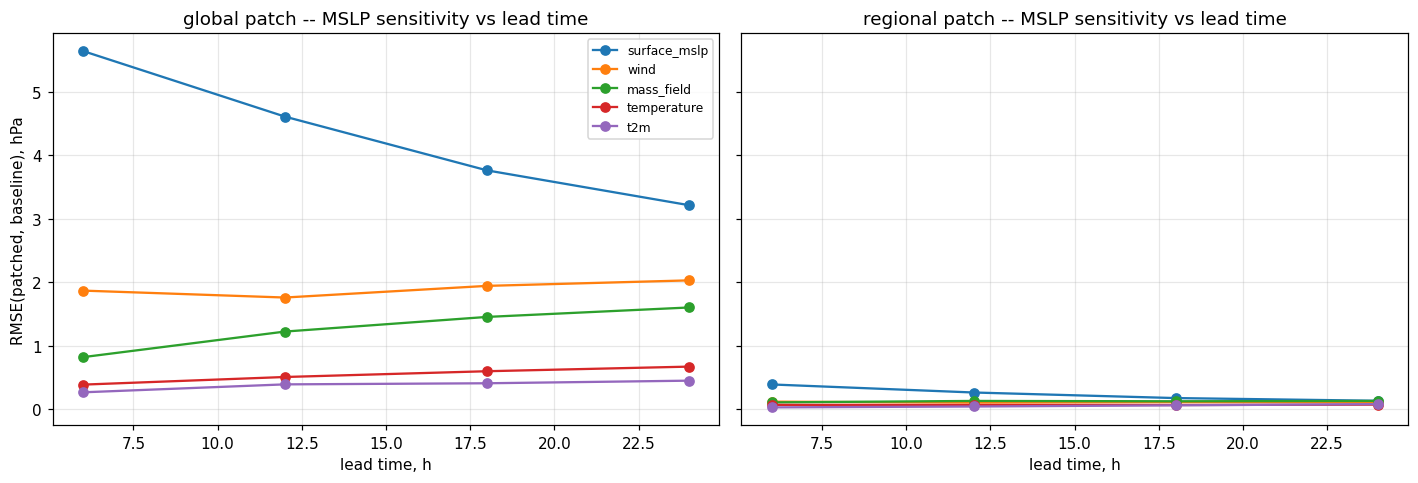

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, scope in zip(axes, ['global', 'regional']):
    for component in COMPONENTS:
        sub = df[(df.date == 'storm') & (df.scope == scope) & (df.component == component) & (df['var'] == 'MSLP')]
        sub = sub.sort_values('lead_hours')
        ax.plot(sub.lead_hours, sub.metric1_rmse_patch_baseline, marker='o', label=component)
    ax.set_xlabel('lead time, h')
    ax.set_title(f'{scope} patch -- MSLP sensitivity vs lead time')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('RMSE(patched, baseline), hPa')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/sensitivity_vs_leadtime_MSLP.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Storm-focused weighted RMSE vs plain area-weighted (storm case only)

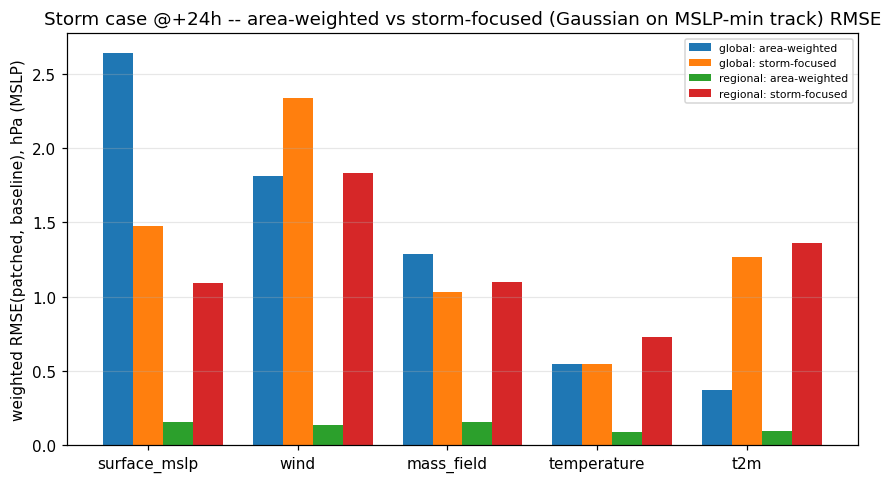

In [5]:
sub = df[(df.date == 'storm') & (df.lead_hours == 24) & (df['var'] == 'MSLP')]
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(COMPONENTS))
width = 0.2
for i, scope in enumerate(['global', 'regional']):
    s = sub[sub.scope == scope].set_index('component').reindex(COMPONENTS)
    ax.bar(x + (i - 0.5) * width * 2, s['weighted_rmse_area'], width, label=f'{scope}: area-weighted')
    ax.bar(x + (i - 0.5) * width * 2 + width, s['weighted_rmse_storm'], width, label=f'{scope}: storm-focused')
ax.set_xticks(x)
ax.set_xticklabels(COMPONENTS)
ax.set_ylabel('weighted RMSE(patched, baseline), hPa (MSLP)')
ax.set_title('Storm case @+24h -- area-weighted vs storm-focused (Gaussian on MSLP-min track) RMSE')
ax.legend(fontsize=7)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/weighted_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

If storm-focused (Gaussian-on-track) weighting gives a *larger* value than plain
area-weighting for a given component, that component's influence is concentrated right at the
storm rather than spread evenly across the domain -- i.e. removing real information about that
component specifically hurts the storm forecast, not just the forecast in general.

## 5. Error maps: baseline vs truth, patched vs truth, patched vs baseline (+24h, China zoom)

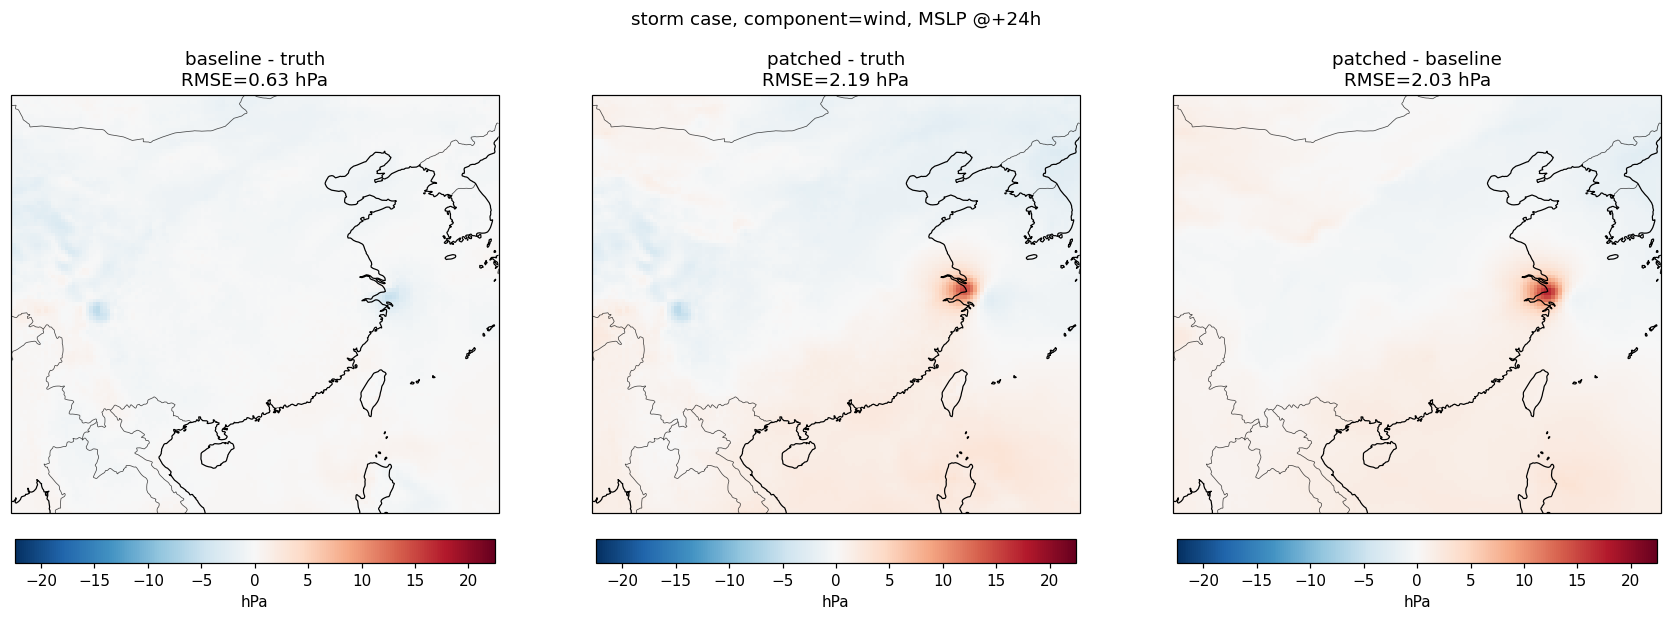

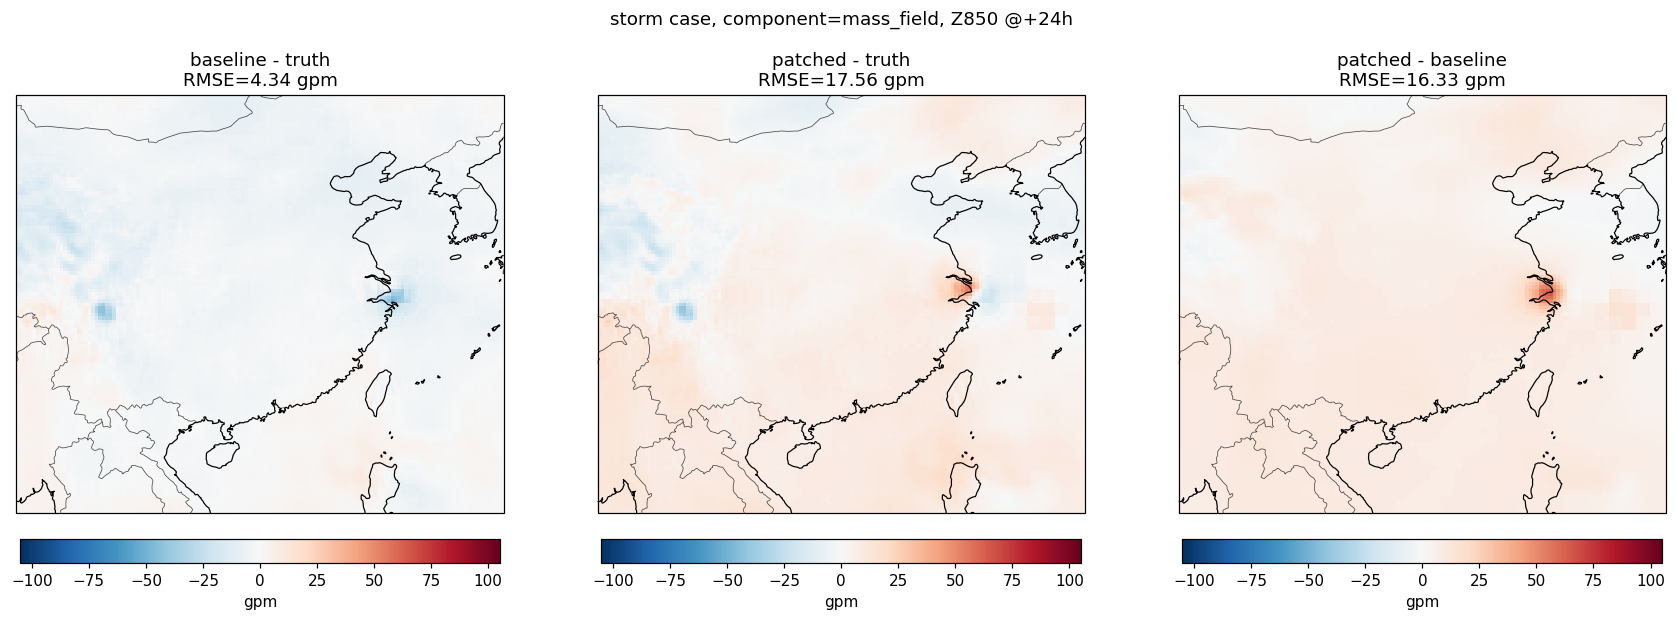

In [6]:
def plot_error_maps(date_label, var_label, component):
    d = maps[(date_label, var_label, component)]
    truth, baseline, patched, unit = d['truth'], d['baseline'], d['patched'], d['unit']
    lat, lon = lat_full, lon_full
    panels = [
        ('baseline - truth', baseline - truth),
        ('patched - truth', patched - truth),
        ('patched - baseline', patched - baseline),
    ]
    vmax = np.nanmax(np.abs([p[1] for p in panels])) * 0.8
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), subplot_kw={'projection': ccrs.PlateCarree()})
    for ax, (title, field) in zip(axes, panels):
        ax.set_extent(CHINA_EXTENT, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)
        im = ax.pcolormesh(lon, lat, field, transform=ccrs.PlateCarree(), cmap='RdBu_r',
                            vmin=-vmax, vmax=vmax)
        plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.85, label=unit)
        rmse = np.sqrt(np.nanmean(field ** 2))
        ax.set_title(f'{title}\nRMSE={rmse:.2f} {unit}')
    fig.suptitle(f'{date_label} case, component={component}, {var_label} @+24h', y=1.03)
    plt.tight_layout()
    safe = f'{date_label}_{component}_{var_label}'
    plt.savefig(f'{FIG_DIR}/errormaps_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_error_maps('storm', 'MSLP', 'wind')
plot_error_maps('storm', 'Z850', 'mass_field')

## Summary

- Metric 4 (relative sensitivity matrix) shows which input components the model leans on for
  each output variable, and whether that coupling is mostly diagonal (self-variable) or
  cross-variable (physical balance enforced internally).
- Metric 2 (ΔRMSE vs truth) is the most direct causal claim: it tells us whether removing real
  information about a component actually degrades forecast *accuracy*, not just shifts the
  forecast away from baseline.
- The storm-focused weighted RMSE (Section 4) lets us tell apart "this component matters
  everywhere" from "this component specifically matters for the typhoon."
- All raw model outputs (baseline + every patched variant, both dates) are cached in
  `results/patching_experiment/*.npz`, and the derived per-variable/lead-time metrics table in
  `results/patching_experiment/metrics_summary.pkl`, so further slicing doesn't require
  rerunning Aurora.